# HOG

## Dataset and preparation

The images live in `vehicles/r7bthvstxw-1`, one folder per vehicle type. We convert them to
grayscale, resize to 128 x 128 and scale the pixel values to [0, 1]. HOG compares gradients between
images, so they all need the same size for the descriptors to have the same length.

The task asks for at least three images covering simple and complex scenes. We use four images from
the dataset rather than built-in sample images, so the results apply to the data we will classify
later.

Run the cells from the top. If packages are missing, run `%pip install pillow numpy matplotlib`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
# Run the notebook with this folder as the working directory.
# In the group repository the data folder is called "vehicle-type-detection/r7bthvstxw-1".
data_dir = Path("vehicles/r7bthvstxw-1")
if not data_dir.exists():
    data_dir = Path("vehicle-type-detection/r7bthvstxw-1")
if not data_dir.exists():
    raise FileNotFoundError(f"Fant ingen datamappe på {data_dir.resolve()}")

image_size = (128, 128)

# Four scenes of increasing complexity.
selected = [
    ("Simple: sedan", "sedan/PIC_11.jpg"),
    ("Textured: hatchback", "hatchback/PIC_97.jpg"),
    ("Cluttered: pickup", "pickup/PIC_353.jpg"),
    ("Other shape: motorcycle", "motorcycle/PIC_75.jpg"),
]


def load_grey(path, size=image_size):
    """Load one image as grayscale in [0, 1] and resize it to a common size."""
    with Image.open(path) as image:
        original_size = image.size  # (width, height)
        image = image.convert("L")  # L means grayscale.
        image = image.resize(size)
        return np.asarray(image, dtype=np.float64) / 255.0, original_size


images = {}
for name, relative in selected:
    path = data_dir / relative
    if not path.exists():
        raise FileNotFoundError(f"Fant ikke {path}")
    images[name], original = load_grey(path)
    print(f"{name:26s} {relative:24s} original {original[0]}x{original[1]} -> {image_size[0]}x{image_size[1]}")

Simple: sedan              sedan/PIC_11.jpg         original 693x448 -> 128x128
Textured: hatchback        hatchback/PIC_97.jpg     original 581x449 -> 128x128
Cluttered: pickup          pickup/PIC_353.jpg       original 701x470 -> 128x128
Other shape: motorcycle    motorcycle/PIC_75.jpg    original 469x727 -> 128x128


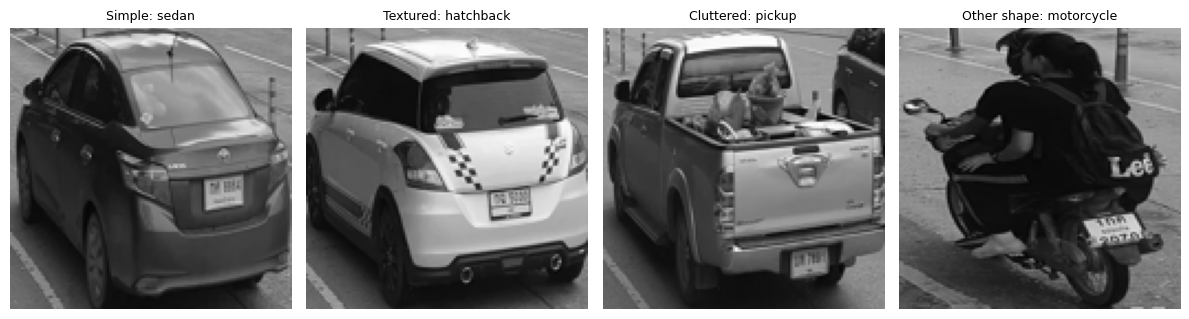

In [3]:
fig, axes = plt.subplots(1, len(images), figsize=(3 * len(images), 3.2), squeeze=False)

for col, (name, image) in enumerate(images.items()):
    axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].axis("off")

plt.tight_layout()
plt.show()

## Gradient Computation

HOG is built on the image gradient, using the mask `[-1, 0, 1]` along each axis with no smoothing
first:

$$G_x(x,y) = I(x,y+1) - I(x,y-1), \qquad G_y(x,y) = I(x+1,y) - I(x-1,y)$$

$$m = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan2(G_y, G_x)$$

The direction is used **unsigned**, folded into $[0^\circ, 180^\circ)$, so a light-to-dark edge and
the dark-to-light edge on the other side of the same object fall in the same bin. We test that
choice later.

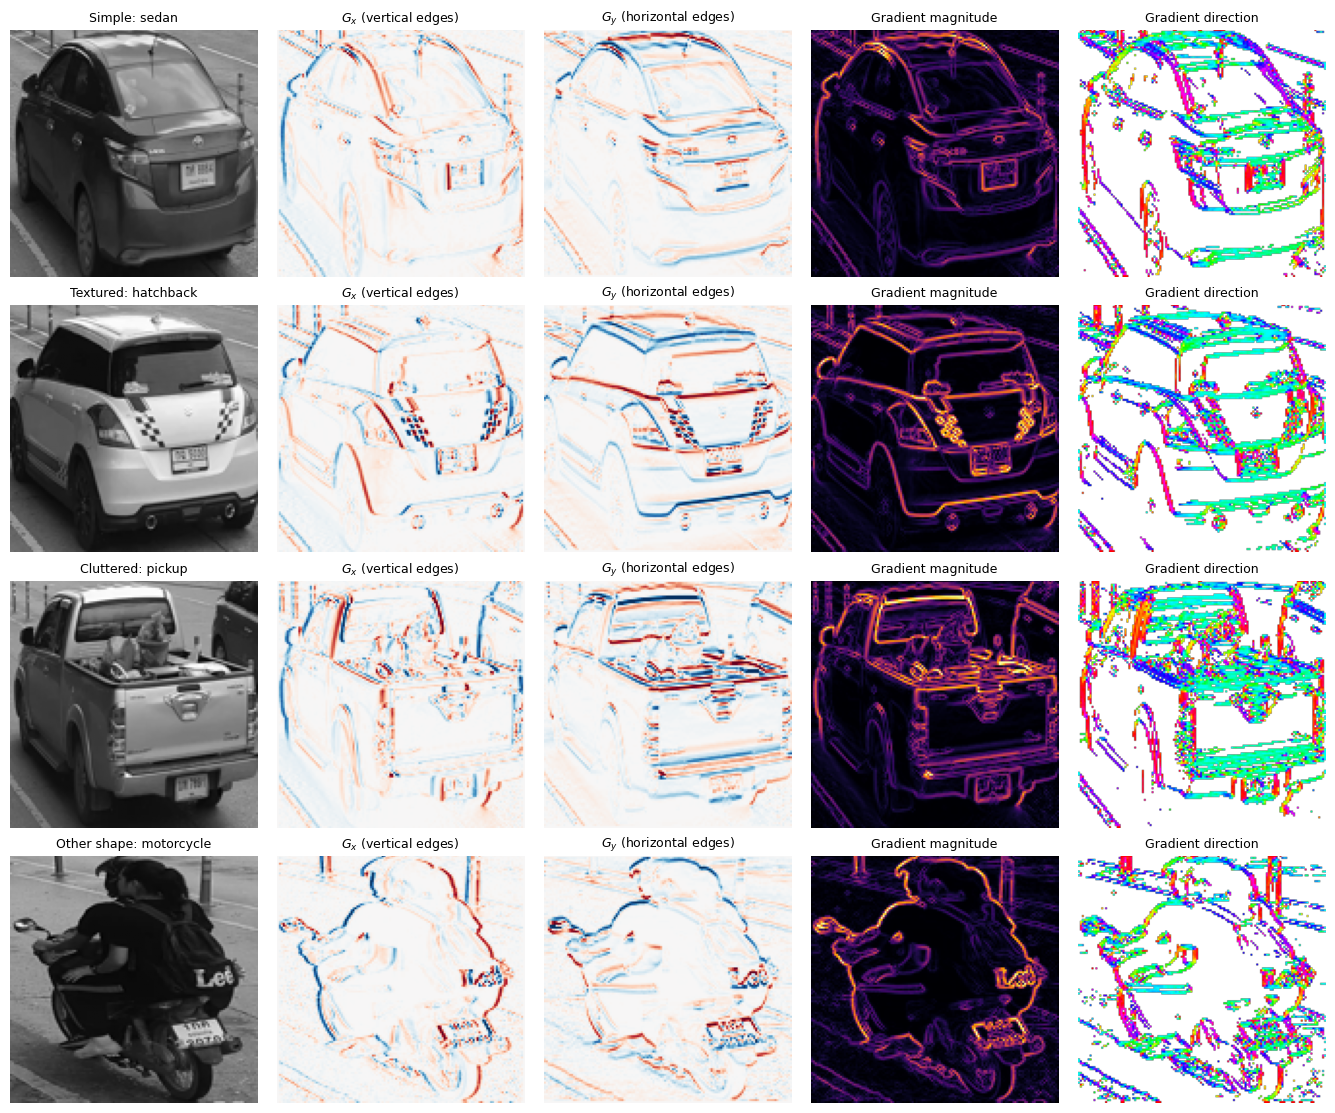

Image                      | Mean gradient  | Pixels with magnitude > 0.08
Simple: sedan              |         0.0818 |                           30.7%
Textured: hatchback        |         0.1033 |                           33.1%
Cluttered: pickup          |         0.1161 |                           40.7%
Other shape: motorcycle    |         0.0866 |                           29.7%


In [4]:
def blur(image, sigma):
    """Separable Gaussian filter, written with numpy alone."""
    if sigma <= 0:
        return np.asarray(image, dtype=np.float64)
    radius = max(1, int(round(3 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-(offsets ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()
    result = np.asarray(image, dtype=np.float64)
    for axis in (0, 1):
        padding = [(radius, radius) if a == axis else (0, 0) for a in (0, 1)]
        padded = np.pad(result, padding, mode="edge")
        blurred = np.zeros_like(result)
        for weight, offset in zip(kernel, offsets):
            start = offset + radius
            blurred += weight * (padded[start:start + result.shape[0], :] if axis == 0
                                 else padded[:, start:start + result.shape[1]])
        result = blurred
    return result


def gradients(image, operator="central"):
    """Gradient in x and y. The default is the mask [-1, 0, 1] of Dalal and Triggs.

    The alternatives are only used in the ablation further down: a forward
    difference, a Sobel operator, and the same [-1, 0, 1] applied after a blur.
    """
    image = np.asarray(image, dtype=np.float64)
    if image.ndim != 2:
        raise ValueError("gradients expects a grayscale image (2D)")

    gx = np.zeros_like(image)
    gy = np.zeros_like(image)
    if operator == "forward":
        gx[:, :-1] = image[:, 1:] - image[:, :-1]
        gy[:-1, :] = image[1:, :] - image[:-1, :]
        return gx, gy
    if operator == "sobel":
        # Sobel is [-1, 0, 1] along one axis and the smoothing [1, 2, 1] along the other.
        padded = np.pad(image, 1, mode="edge")
        for dy in (-1, 0, 1):
            weight = 2.0 if dy == 0 else 1.0
            row = padded[1 + dy:1 + dy + image.shape[0], :]
            gx += weight * (row[:, 2:] - row[:, :-2])
        for dx in (-1, 0, 1):
            weight = 2.0 if dx == 0 else 1.0
            col = padded[:, 1 + dx:1 + dx + image.shape[1]]
            gy += weight * (col[2:, :] - col[:-2, :])
        return gx / 4.0, gy / 4.0
    if operator == "blurred":
        image = blur(image, 1.0)
    gx[:, 1:-1] = image[:, 2:] - image[:, :-2]
    gy[1:-1, :] = image[2:, :] - image[:-2, :]
    return gx, gy


def gradient_magnitude_and_angle(image, signed=False, operator="central"):
    """Gradient magnitude and direction. Unsigned folds the direction into [0, 180)."""
    gx, gy = gradients(image, operator)
    span = 360.0 if signed else 180.0
    return np.hypot(gx, gy), np.mod(np.rad2deg(np.arctan2(gy, gx)), span)


fig, axes = plt.subplots(len(images), 5, figsize=(13.5, 2.8 * len(images)), squeeze=False)

for row, (name, image) in enumerate(images.items()):
    gx, gy = gradients(image)
    magnitude, angle = gradient_magnitude_and_angle(image)
    panels = [
        (image, name, dict(cmap="gray", vmin=0, vmax=1)),
        (gx, "$G_x$ (vertical edges)", dict(cmap="RdBu_r", vmin=-0.6, vmax=0.6)),
        (gy, "$G_y$ (horizontal edges)", dict(cmap="RdBu_r", vmin=-0.6, vmax=0.6)),
        (magnitude, "Gradient magnitude", dict(cmap="inferno", vmin=0, vmax=0.8)),
        # Direction is only meaningful where there is an edge, so weak gradients are hidden.
        (np.where(magnitude > 0.08, angle, np.nan), "Gradient direction",
         dict(cmap="hsv", vmin=0, vmax=180)),
    ]
    for ax, (panel, title, options) in zip(axes[row], panels):
        ax.imshow(panel, **options)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()

print("Image                      | Mean gradient  | Pixels with magnitude > 0.08")
for name, image in images.items():
    magnitude, _ = gradient_magnitude_and_angle(image)
    print(f"{name:26s} | {magnitude.mean():14.4f} | {np.mean(magnitude > 0.08):31.1%}")

## HOG Implementation

Three steps:

1. **Cells.** Square cells of `cell` x `cell` pixels. Every pixel votes with its gradient
   *magnitude*, split linearly between the two nearest bin centres, wrapping around at both ends.
2. **Blocks.** Overlapping blocks of `block` x `block` cells, stride one cell. Most cells therefore
   appear in several blocks and are normalised differently each time.
3. **Normalisation.** L2-Hys: unit L2 norm, clip at 0.2, renormalise.

Descriptor length:

$$\underbrace{(\lfloor H/c\rfloor - b + 1)(\lfloor W/c\rfloor - b + 1)}_{\text{blocks}}
\times \underbrace{b^2 \times \text{bins}}_{\text{per block}}$$

In [5]:
def hog_cells(image, cell=8, bins=9, signed=False, operator="central"):
    """Orientation histogram per cell, with linear voting between neighbouring bins."""
    magnitude, angle = gradient_magnitude_and_angle(image, signed=signed, operator=operator)
    span = 360.0 if signed else 180.0

    height, width = image.shape
    rows, cols = height // cell, width // cell
    if rows < 1 or cols < 1:
        raise ValueError("cell is larger than the image")

    # Split into cells: (rows, cell, cols, cell) -> (rows, cols, cell, cell).
    magnitude = magnitude[:rows * cell, :cols * cell].reshape(rows, cell, cols, cell)
    angle = angle[:rows * cell, :cols * cell].reshape(rows, cell, cols, cell)
    magnitude = magnitude.transpose(0, 2, 1, 3)
    angle = angle.transpose(0, 2, 1, 3)

    # Position between bin centres. The centre of bin b sits at (b + 0.5) * width.
    bin_width = span / bins
    position = angle / bin_width - 0.5
    lower = np.floor(position).astype(int)
    fraction = position - lower

    histogram = np.zeros((rows, cols, bins))
    for index, weight in ((lower, 1.0 - fraction), (lower + 1, fraction)):
        flat_bin = np.mod(index, bins).reshape(rows * cols, -1).ravel()
        flat_cell = np.arange(rows * cols).repeat(cell * cell)
        np.add.at(histogram.reshape(-1), flat_cell * bins + flat_bin,
                  (magnitude * weight).reshape(rows * cols, -1).ravel())
    return histogram


def hog(image, cell=8, block=2, bins=9, signed=False, eps=1e-6,
        operator="central", norm="L2-Hys"):
    """HOG descriptor: cells, overlapping blocks and block normalisation.

    The defaults are the settings of Dalal and Triggs. `operator` and `norm`
    are only varied in the ablation further down.
    """
    if not all(isinstance(v, (int, np.integer)) and v >= 1 for v in (cell, block, bins)):
        raise ValueError("cell, block and bins must be integers greater than zero.")

    histogram = hog_cells(image, cell=cell, bins=bins, signed=signed, operator=operator)
    rows, cols, _ = histogram.shape
    if block > min(rows, cols):
        raise ValueError("block is larger than the number of cells.")

    block_rows, block_cols = rows - block + 1, cols - block + 1
    descriptor = np.empty((block_rows, block_cols, block * block * bins))
    for i in range(block_rows):
        for j in range(block_cols):
            v = histogram[i:i + block, j:j + block].ravel()
            if norm == "L1":
                v = v / (v.sum() + eps)
            elif norm == "L1-sqrt":
                v = np.sqrt(v / (v.sum() + eps))
            elif norm == "L2":
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)
            else:                                             # L2-Hys
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)    # L2
                v = np.minimum(v, 0.2)                        # Hys: clip the peaks
                v = v / np.sqrt((v ** 2).sum() + eps ** 2)
            descriptor[i, j] = v
    return descriptor.ravel()


def descriptor_length(shape, cell, block, bins):
    """Descriptor length from the formula above."""
    rows, cols = shape[0] // cell, shape[1] // cell
    return (rows - block + 1) * (cols - block + 1) * block * block * bins

In [6]:
# Check against synthetic edges where the answer is known.
vertical_edge = np.zeros((32, 32))
vertical_edge[:, 16:] = 1.0          # vertical edge -> horizontal gradient, 0 degrees
horizontal_edge = np.zeros((32, 32))
horizontal_edge[16:, :] = 1.0        # horizontal edge -> vertical gradient, 90 degrees
diagonal_edge = np.tril(np.ones((32, 32)))   # 45 degree edge

print("Bin centres (degrees):", np.round((np.arange(9) + 0.5) * 20, 0))
for name, test, cell_index in [("Vertical edge", vertical_edge, (2, 1)),
                               ("Horizontal edge", horizontal_edge, (1, 2)),
                               ("45 degree edge", diagonal_edge, (2, 2))]:
    cell_histogram = hog_cells(test, cell=8, bins=9)[cell_index]
    print(f"{name:16s} {np.round(cell_histogram / cell_histogram.sum(), 3)}")

print(f"\nLength formula: {descriptor_length(image_size, 8, 2, 9)} == "
      f"{hog(np.zeros(image_size)).size}")

Bin centres (degrees): [ 10.  30.  50.  70.  90. 110. 130. 150. 170.]
Vertical edge    [0.5 0.  0.  0.  0.  0.  0.  0.  0.5]
Horizontal edge  [0. 0. 0. 0. 1. 0. 0. 0. 0.]
45 degree edge   [0.   0.   0.   0.   0.   0.   0.75 0.25 0.  ]

Length formula: 8100 == 8100


The synthetic tests behave as the theory predicts. The 45 degree edge has a gradient
perpendicular to it at $135^\circ$, which falls between the bin centres at $130^\circ$ and
$150^\circ$; the vote splits 0.75 / 0.25 and recovers exactly $135^\circ$. The vertical edge splits
evenly between the first and last bin, which confirms that the wrap-around works.

## Comparison with scikit-image

The task allows the descriptor to be computed with a library such as OpenCV or scikit-image. We
wrote our own so that every step is visible, and use `skimage.feature.hog` here as an independent
check on the same images and the same settings.

In [7]:
from skimage.feature import hog as skimage_hog

print(f"{'Image':26s} {'ours':>7s} {'skimage':>8s} {'cosine':>8s}")
for name, image in images.items():
    ours = hog(image, cell=8, block=2, bins=9)
    theirs = skimage_hog(image, orientations=9, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), block_norm="L2-Hys")
    similarity = float(ours @ theirs / (np.linalg.norm(ours) * np.linalg.norm(theirs)))
    print(f"{name:26s} {ours.size:7d} {theirs.size:8d} {similarity:8.4f}")

Image                         ours  skimage   cosine
Simple: sedan                 8100     8100   0.9855
Textured: hatchback           8100     8100   0.9812
Cluttered: pickup             8100     8100   0.9858
Other shape: motorcycle       8100     8100   0.9841


The two descriptors have identical length and agree closely, but they are not bit identical, and
the difference is a documented design choice rather than an error. `skimage` assigns each pixel to a
single orientation bin where we split the vote between the two nearest, and it averages the
magnitude over the cell where we sum it. Both are legitimate readings of Dalal and Triggs. The
agreement is high enough to confirm the implementation.

## Visualization

Each cell is drawn as a star of line segments, one per orientation bin, with length proportional to
the bin weight. Segments are drawn perpendicular to the gradient so they follow the edge.

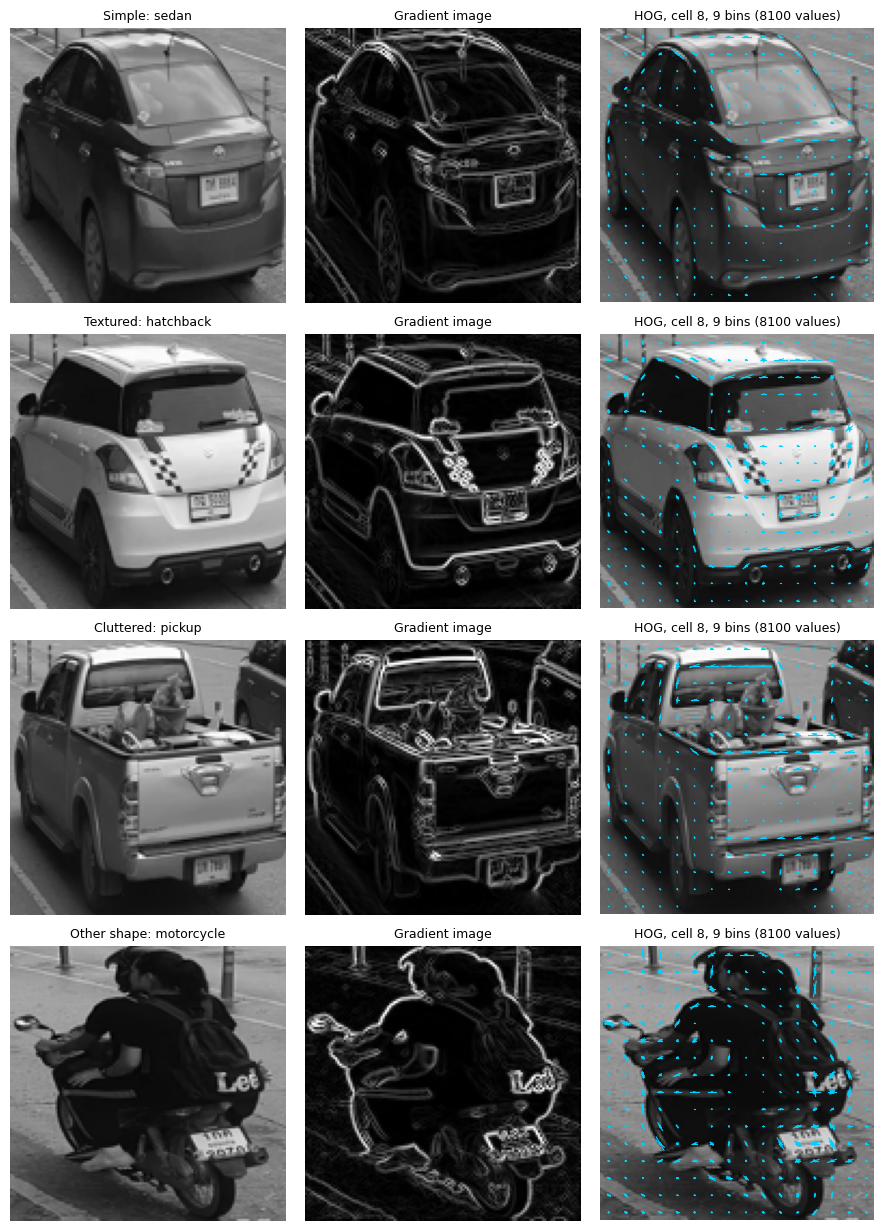

In [8]:
def draw_hog(cell_histogram, cell, ax, scale=0.9, color="#00d0ff"):
    """Draw one star per cell on top of the image already in ax."""
    rows, cols, bins = cell_histogram.shape
    peak = cell_histogram.max() or 1.0
    angles = (np.arange(bins) + 0.5) * (np.pi / bins)

    for i in range(rows):
        for j in range(cols):
            center_y, center_x = (i + 0.5) * cell, (j + 0.5) * cell
            for b, angle in enumerate(angles):
                length = scale * 0.5 * cell * cell_histogram[i, j, b] / peak
                if length < 0.05:
                    continue
                # The edge is perpendicular to the gradient, hence cos/-sin.
                dy, dx = length * np.cos(angle), -length * np.sin(angle)
                ax.plot([center_x - dx, center_x + dx], [center_y - dy, center_y + dy],
                        color=color, linewidth=0.8)
    ax.set_xlim(0, cols * cell)
    ax.set_ylim(rows * cell, 0)


fig, axes = plt.subplots(len(images), 3, figsize=(9, 3.1 * len(images)), squeeze=False)

features = {}
for row, (name, image) in enumerate(images.items()):
    magnitude, _ = gradient_magnitude_and_angle(image)
    features[name] = hog(image)

    axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(name, fontsize=9)

    axes[row, 1].imshow(magnitude, cmap="gray", vmin=0, vmax=0.8)
    axes[row, 1].set_title("Gradient image", fontsize=9)

    axes[row, 2].imshow(image, cmap="gray", vmin=0, vmax=1)
    draw_hog(hog_cells(image, cell=8, bins=9), 8, axes[row, 2])
    axes[row, 2].set_title(f"HOG, cell 8, 9 bins ({len(features[name])} values)", fontsize=9)

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

### What the visualisation shows

Share of pixels above the gradient threshold: simple 30.7 %, textured 33.1 %, cluttered 40.7 %,
motorcycle 29.7 %. The chequered decal and the background vehicles raise the figure without saying
anything about the target, and HOG has no segmentation step to separate them.

All four peak at 90 degrees, which is the gradient direction and so corresponds to vertical edges.
The orientation profile alone therefore does not separate the classes; it is *where* the directions
occur that carries the information, which is what the cell grid encodes.

## Block Normalisation

Block normalisation is the step that is easiest to leave out and hardest to justify from a picture,
so we test it directly. Three changes are applied to the same image and the descriptor is compared
with the original by cosine similarity, once with L2-Hys blocks and once using the raw cell
histograms:

* a **global** intensity change, the same everywhere;
* a **gamma** change, monotone but non-linear;
* a **vignette**, a multiplier rising from left to right, which changes contrast *differently in
  different parts of the image*.

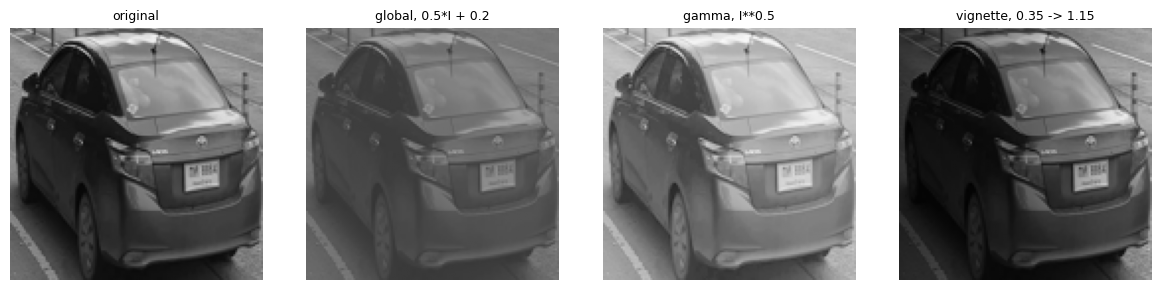

Change                      With L2-Hys blocks   Raw cell histograms
global, 0.5*I + 0.2                     1.0000                1.0000
gamma, I**0.5                           0.9957                0.9738
vignette, 0.35 -> 1.15                  0.9918                0.9620


In [9]:
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


name = names[0] if "names" in dir() else list(images)[0]
base = images[name]
h, w = base.shape
vignette = np.linspace(0.35, 1.15, w)[None, :] * np.ones((h, 1))

variants = {
    "global, 0.5*I + 0.2": np.clip(0.5 * base + 0.2, 0, 1),
    "gamma, I**0.5": base ** 0.5,
    "vignette, 0.35 -> 1.15": np.clip(base * vignette, 0, 1),
}

fig, axes = plt.subplots(1, 4, figsize=(12, 2.9), squeeze=False)
axes[0, 0].imshow(base, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("original", fontsize=9)
for ax, (label, variant) in zip(axes[0, 1:], variants.items()):
    ax.imshow(variant, cmap="gray", vmin=0, vmax=1)
    ax.set_title(label, fontsize=9)
for ax in axes[0]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{'Change':26s} {'With L2-Hys blocks':>19s} {'Raw cell histograms':>21s}")
for label, variant in variants.items():
    with_blocks = cosine(hog(base), hog(variant))
    cells_only = cosine(hog_cells(base, cell=8, bins=9).ravel(),
                        hog_cells(variant, cell=8, bins=9).ravel())
    print(f"{label:26s} {with_blocks:19.4f} {cells_only:21.4f}")

A global intensity change is handled perfectly **with or without** blocks, both cosines are exactly
1.0000. That is worth stating because it is often presented as the benefit of block normalisation
and it is not: `[-1, 0, 1]` is linear, so scaling the whole image scales every gradient by the same
factor, and a cosine similarity is scale invariant by construction.

Non-uniform illumination is where normalisation earns its place. Under the vignette the
block-normalised descriptor keeps a cosine of 0.9918 while the raw cell histograms drop to 0.9620,
so the deviation falls from 0.0380 to 0.0082, a reduction of 78 %. The mechanism is local: each
block divides by its own norm, so a block in the dark left part of the image is rescaled by a
different amount than one on the bright right, and the differences largely cancel. This is also the
reason the block size matters at all, which the parameter study below measures.

## Comparing the Images

The **orientation profile** sums the descriptor per bin and shows which edge directions dominate.
The **cosine similarity** between two full descriptors is 1 when they point the same way.

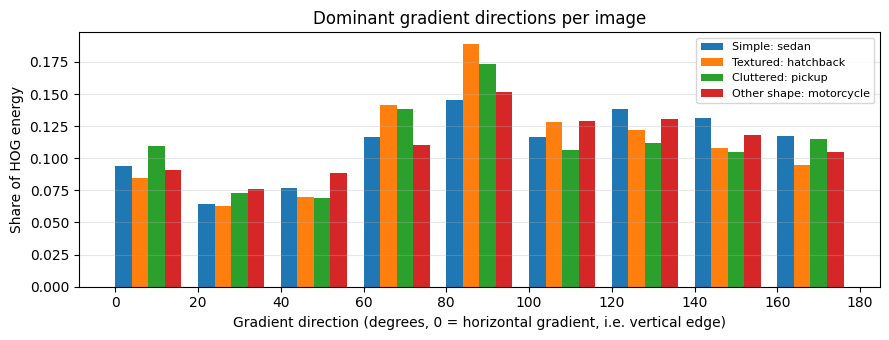

In [10]:
def orientation_profile(descriptor, bins=9):
    """Share of the HOG energy per orientation bin."""
    profile = descriptor.reshape(-1, bins).sum(axis=0)
    return profile / profile.sum()


names = list(features)
bins = 9
centers = (np.arange(bins) + 0.5) * 180 / bins

fig, ax = plt.subplots(figsize=(9, 3.5))
width = 180 / bins / (len(names) + 1)
for i, name in enumerate(names):
    ax.bar(centers + (i - len(names) / 2) * width, orientation_profile(features[name]),
           width=width, label=name)
ax.set(xlabel="Gradient direction (degrees, 0 = horizontal gradient, i.e. vertical edge)",
       ylabel="Share of HOG energy",
       title="Dominant gradient directions per image")
ax.set_xticks(np.arange(0, 181, 20))
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

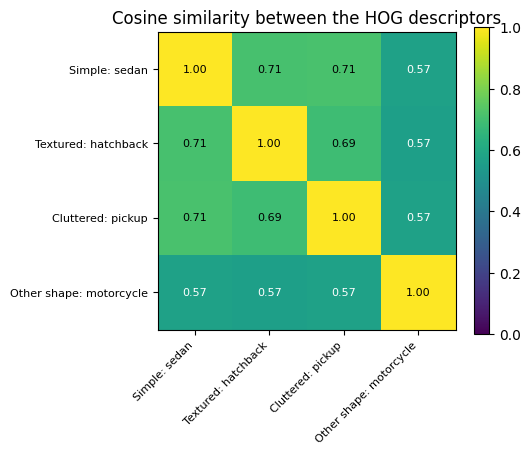

Statistics per image
Simple: sedan              length=8100  mean=0.123  share near zero=11.5%  strongest direction=90 degrees
Textured: hatchback        length=8100  mean=0.118  share near zero=17.7%  strongest direction=90 degrees
Cluttered: pickup          length=8100  mean=0.121  share near zero=14.7%  strongest direction=90 degrees
Other shape: motorcycle    length=8100  mean=0.130  share near zero=7.1%  strongest direction=90 degrees


In [11]:
# Cosine similarity between the descriptors.
F = np.array([features[name] for name in names])
F = F / np.linalg.norm(F, axis=1, keepdims=True)
similarity = F @ F.T

fig, ax = plt.subplots(figsize=(5.5, 4.6))
image_handle = ax.imshow(similarity, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{similarity[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if similarity[i, j] < 0.6 else "black")
ax.set_title("Cosine similarity between the HOG descriptors")
fig.colorbar(image_handle, ax=ax)
plt.tight_layout()
plt.show()

print("Statistics per image")
for name in names:
    descriptor = features[name]
    profile = orientation_profile(descriptor)
    print(f"{name:26s} length={len(descriptor)}  mean={descriptor.mean():.3f}  "
          f"share near zero={np.mean(descriptor < 0.01):.1%}  "
          f"strongest direction={centers[profile.argmax()]:.0f} degrees")

## Experimentation

We measure the three parameters instead of only discussing them. 40 images per class are encoded
with each setting, and we report:

* the **cosine gap**: mean similarity within a class minus mean similarity between classes;
* **leave-one-out 1-NN accuracy**; chance is 0.200 on a balanced set.

This is not a classifier for Assignment 3, only a way of asking which settings carry more class
information.

In [12]:
rng = np.random.default_rng(0)
per_class = 40

subset_images = []
subset_labels = []
for class_dir in sorted(p for p in data_dir.iterdir() if p.is_dir()):
    paths = sorted(class_dir.glob("*.jpg")) + sorted(class_dir.glob("*.JPG"))
    chosen = rng.choice(len(paths), min(per_class, len(paths)), replace=False)
    for index in sorted(chosen):
        grey, _ = load_grey(paths[index])
        subset_images.append(grey)
        subset_labels.append(class_dir.name)

subset_images = np.array(subset_images)
subset_labels = np.array(subset_labels)
print(f"Loaded {len(subset_images)} images for the parameter study.")
for label in np.unique(subset_labels):
    print(f"{label}: {np.sum(subset_labels == label)} images")

Loaded 200 images for the parameter study.
hatchback: 40 images
motorcycle: 40 images
pickup: 40 images
sedan: 40 images
suv: 40 images


In [13]:
def encode(**parameters):
    return np.stack([hog(image, **parameters) for image in subset_images])


def evaluate(descriptors):
    """Cosine gap and leave-one-out 1-NN accuracy."""
    normalised = descriptors / np.linalg.norm(descriptors, axis=1, keepdims=True)
    similarity = normalised @ normalised.T

    same_class = subset_labels[:, None] == subset_labels[None, :]
    diagonal = np.eye(len(subset_labels), dtype=bool)
    within = similarity[same_class & ~diagonal].mean()
    between = similarity[~same_class].mean()

    np.fill_diagonal(similarity, -2.0)   # an image cannot be its own neighbour
    predicted = subset_labels[similarity.argmax(axis=1)]
    return within - between, (predicted == subset_labels).mean(), predicted


settings = [("Cell size", 4, dict(cell=4, block=2, bins=9)),
            ("Cell size", 8, dict(cell=8, block=2, bins=9)),
            ("Cell size", 16, dict(cell=16, block=2, bins=9)),
            ("Cell size", 32, dict(cell=32, block=2, bins=9)),
            ("Block size", 1, dict(cell=8, block=1, bins=9)),
            ("Block size", 2, dict(cell=8, block=2, bins=9)),
            ("Block size", 3, dict(cell=8, block=3, bins=9)),
            ("Bins", 4, dict(cell=8, block=2, bins=4)),
            ("Bins", 9, dict(cell=8, block=2, bins=9)),
            ("Bins", 12, dict(cell=8, block=2, bins=12)),
            ("Bins", 18, dict(cell=8, block=2, bins=18))]

results = []
predictions = {}
for group, value, parameters in settings:
    descriptors = encode(**parameters)
    gap, accuracy, predicted = evaluate(descriptors)
    predictions[(group, value)] = predicted
    results.append((group, value, descriptors.shape[1], gap, accuracy))

print(f"{'Parameter':16s} {'Value':>6s} {'Length':>8s} {'Gap':>7s} {'1-NN':>7s}")
previous = None
for group, value, length, gap, accuracy in results:
    if group != previous:
        print("-" * 48)
        previous = group
    print(f"{group:16s} {value:6d} {length:8d} {gap:7.3f} {accuracy:7.3f}")

Parameter         Value   Length     Gap    1-NN
------------------------------------------------
Cell size             4    34596   0.020   0.745
Cell size             8     8100   0.026   0.755
Cell size            16     1764   0.029   0.795
Cell size            32      324   0.019   0.765
------------------------------------------------
Block size            1     2304   0.015   0.765
Block size            2     8100   0.026   0.755
Block size            3    15876   0.031   0.790
------------------------------------------------
Bins                  4     3600   0.016   0.760
Bins                  9     8100   0.026   0.755
Bins                 12    10800   0.028   0.765
Bins                 18    16200   0.029   0.770


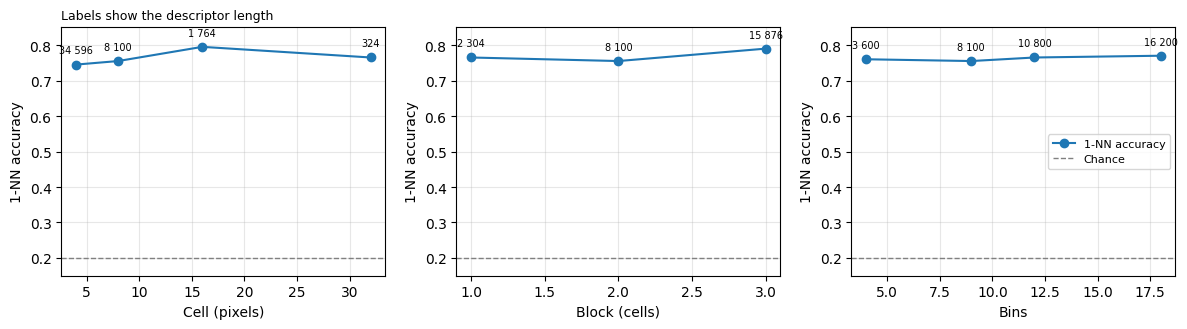

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), squeeze=False)

for ax, group, xlabel in zip(axes[0], ["Cell size", "Block size", "Bins"],
                             ["Cell (pixels)", "Block (cells)", "Bins"]):
    rows = [r for r in results if r[0] == group]
    values = [r[1] for r in rows]
    ax.plot(values, [r[4] for r in rows], "o-", color="tab:blue", label="1-NN accuracy")
    ax.axhline(0.2, color="gray", linestyle="--", linewidth=1, label="Chance")
    for value, _, length, _, accuracy in [(r[1], r[2], r[2], r[3], r[4]) for r in rows]:
        ax.annotate(f"{length:,}".replace(",", " "), (value, accuracy),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
    ax.set(xlabel=xlabel, ylabel="1-NN accuracy", ylim=(0.15, 0.85))
    ax.grid(alpha=0.3)
axes[0, 0].set_title("Labels show the descriptor length", fontsize=9, loc="left")
axes[0, 2].legend(fontsize=8)
plt.tight_layout()
plt.show()

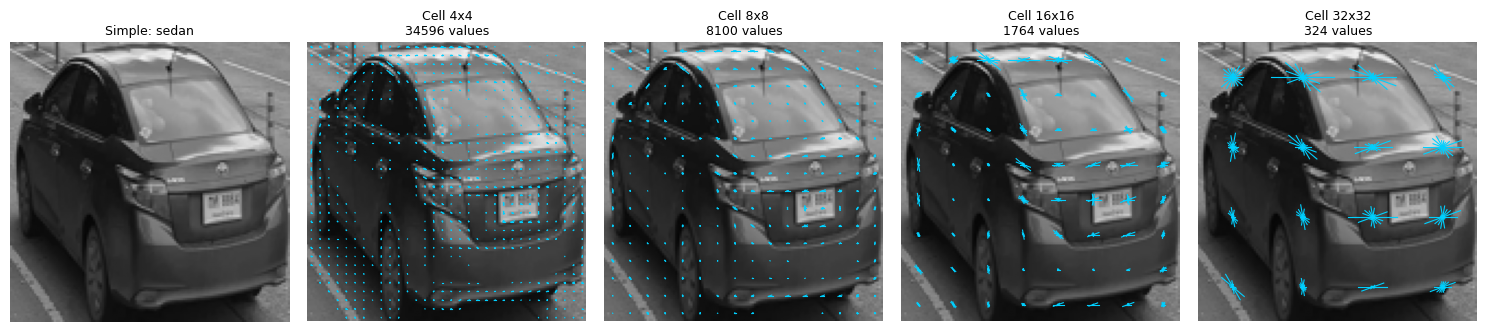

In [15]:
# How does the descriptor look at different cell sizes?
name = names[0]
cell_sizes = [4, 8, 16, 32]
fig, axes = plt.subplots(1, len(cell_sizes) + 1, figsize=(3 * (len(cell_sizes) + 1), 3.2),
                         squeeze=False)

axes[0, 0].imshow(images[name], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(name, fontsize=9)
for col, cell in enumerate(cell_sizes, start=1):
    axes[0, col].imshow(images[name], cmap="gray", vmin=0, vmax=1)
    draw_hog(hog_cells(images[name], cell=cell, bins=9), cell, axes[0, col])
    axes[0, col].set_title(f"Cell {cell}x{cell}\n{descriptor_length(image_size, cell, 2, 9)} values",
                           fontsize=9)
for ax in axes[0]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Is it worth keeping the sign of the gradient direction?
for signed in (False, True):
    descriptors = encode(cell=8, block=2, bins=9, signed=signed)
    gap, accuracy, _ = evaluate(descriptors)
    label = "signed [0, 360)" if signed else "unsigned [0, 180)"
    print(f"{label:20s} length={descriptors.shape[1]:6d}  gap={gap:.3f}  1-NN={accuracy:.3f}")

# Accuracy per class for the coarsest and the finest cell size.
print("\nAccuracy per class")
for value in (8, 32):
    predicted = predictions[("Cell size", value)]
    per_label = "  ".join(f"{label} {np.mean(predicted[subset_labels == label] == label):.2f}"
                          for label in np.unique(subset_labels))
    print(f"  cell {value:2d}: {per_label}")

unsigned [0, 180)    length=  8100  gap=0.026  1-NN=0.755


signed [0, 360)      length=  8100  gap=0.023  1-NN=0.740

Accuracy per class
  cell  8: hatchback 0.50  motorcycle 0.90  pickup 0.80  sedan 0.85  suv 0.72
  cell 32: hatchback 0.50  motorcycle 1.00  pickup 0.75  sedan 0.85  suv 0.72


### Are the differences real?

200 images means one image is half a percentage point. The two settings are compared on the same
images, so the right check is McNemar's test on the images whose prediction changes.

In [17]:
from math import comb


def binomial_p(successes, trials):
    """Two-sided binomial test with p = 0.5, without scipy."""
    if trials == 0:
        return 1.0
    probabilities = [comb(trials, i) for i in range(trials + 1)]
    total = sum(probabilities)
    observed = probabilities[successes]
    # Sum every outcome at least as unlikely as the observed one.
    tail = sum(p for p in probabilities if p <= observed + 1e-12)
    return min(1.0, tail / total)


def mcnemar(correct_a, correct_b):
    """Paired comparison: p value, and how many images change each way."""
    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))
    return binomial_p(min(only_a, only_b), only_a + only_b), only_a, only_b


baseline = predictions[("Cell size", 8)] == subset_labels
print(f"Baseline: cell 8, block 2, 9 bins, accuracy {baseline.mean():.3f}, n = {len(subset_labels)}\n")
print(f"{'Setting':22s} {'Accuracy':>10s} {'Lost':>6s} {'Gained':>7s} {'p':>7s}  Verdict")
for key in [("Cell size", 4), ("Cell size", 16), ("Cell size", 32),
            ("Block size", 1), ("Block size", 3),
            ("Bins", 4), ("Bins", 18)]:
    correct = predictions[key] == subset_labels
    p, lost, gained = mcnemar(baseline, correct)
    verdict = "real" if p < 0.05 else "within noise"
    label = f"{key[0]} {key[1]}"
    print(f"{label:22s} {correct.mean():10.3f} {lost:6d} {gained:7d} {p:7.3f}  {verdict}")

Baseline: cell 8, block 2, 9 bins, accuracy 0.755, n = 200

Setting                  Accuracy   Lost  Gained       p  Verdict
Cell size 4                 0.745     10       8   0.815  within noise
Cell size 16                0.795      9      17   0.169  within noise
Cell size 32                0.765     19      21   0.875  within noise
Block size 1                0.765     12      14   0.845  within noise
Block size 3                0.790      4      11   0.118  within noise
Bins 4                      0.760      6       7   1.000  within noise
Bins 18                     0.770      3       6   0.508  within noise


## Two Choices Taken from the Paper

Two decisions in the implementation were made on the authority of Dalal and Triggs rather than on
evidence from this data: the uncentred `[-1, 0, 1]` gradient with no smoothing first, and L2-Hys
normalisation. Both were chosen after an ablation on a pedestrian dataset, and the cell size result
has already shown one case where a pedestrian-detection recommendation does not transfer. We test
both on the same 200 images, against the same baseline.

In [18]:
ablation = []
for operator, label in [("central", "[-1, 0, 1] (Dalal and Triggs)"),
                        ("forward", "forward difference [-1, 1]"),
                        ("sobel", "Sobel 3x3"),
                        ("blurred", "[-1, 0, 1] after a blur, sigma 1")]:
    gap, accuracy, predicted = evaluate(np.stack([hog(x, operator=operator) for x in subset_images]))
    p, _, _ = mcnemar(baseline, predicted == subset_labels)
    ablation.append(("gradient operator", label, gap, accuracy, p))

for norm in ("L1", "L1-sqrt", "L2", "L2-Hys"):
    gap, accuracy, predicted = evaluate(np.stack([hog(x, norm=norm) for x in subset_images]))
    p, _, _ = mcnemar(baseline, predicted == subset_labels)
    ablation.append(("block normalisation", norm, gap, accuracy, p))

print(f"baseline: cell 8, block 2, 9 bins, accuracy {baseline.mean():.3f}\n")
print(f"{'Group':20s} {'Setting':30s} {'Gap':>7s} {'Accuracy':>9s} {'p':>7s}")
previous = None
for group, label, gap, accuracy, p in ablation:
    if group != previous:
        print("-" * 78)
        previous = group
    print(f"{group:20s} {label:30s} {gap:7.3f} {accuracy:9.3f} {p:7.3f}")

baseline: cell 8, block 2, 9 bins, accuracy 0.755

Group                Setting                            Gap  Accuracy       p
------------------------------------------------------------------------------
gradient operator    [-1, 0, 1] (Dalal and Triggs)    0.026     0.755   1.000
gradient operator    forward difference [-1, 1]       0.022     0.755   1.000
gradient operator    Sobel 3x3                        0.029     0.780   0.180
gradient operator    [-1, 0, 1] after a blur, sigma 1   0.028     0.765   0.804
------------------------------------------------------------------------------
block normalisation  L1                               0.035     0.805   0.031
block normalisation  L1-sqrt                          0.019     0.770   0.453
block normalisation  L2                               0.033     0.785   0.180
block normalisation  L2-Hys                           0.026     0.755   1.000


### What the ablation says

**Neither of the paper's two choices is the best setting here.**

On the **gradient operator**, both variants that beat `[-1, 0, 1]` do so by blurring: Sobel applies
a `[1, 2, 1]` smoothing along the axis perpendicular to the derivative (gap 0.029, accuracy 0.780),
and the fourth variant blurs explicitly (0.028, 0.765). The plain forward difference is the only one
clearly worse. Neither improvement is resolvable, $p = 0.18$ and $p = 0.80$, so this is a direction
rather than a result. But it points the same way as the cell size finding, and for the same reason:
Dalal and Triggs worked on tightly aligned 64 x 128 pedestrian windows from uncompressed images,
while our crops are unaligned, resized by large factors and already JPEG compressed, so the finest
gradients carry proportionally more artefact and less object.

On the **normalisation scheme**, L1 comes out ahead of L2-Hys on both measures, gap 0.035 against
0.026 and accuracy 0.805 against 0.755, and it is the only comparison in this notebook that falls
below $p = 0.05$. That deserves a caveat rather than a conclusion: it is one of eight tests run
against the same baseline, and with eight tests a threshold of 0.05 is crossed by chance about a
third of the time. A Bonferroni-corrected threshold would be 0.006, which $p = 0.031$ does not meet.
The honest statement is that L1 is worth testing properly on more data, not that it is better.

The clipping in L2-Hys exists to stop a single very strong gradient from dominating its block. These
images have a lot of specular highlights on paintwork and glass, which is exactly the situation the
clipping is meant for, so it is a little surprising that plain L2 and L1 do at least as well. Both
observations are worth carrying into Assignment 3 as something to check rather than assume.

### Choice of parameters

No accuracy difference survives the paired test (all $p > 0.11$), so the discussion rests on the
**cosine gap**, which averages over nearly 20 000 image pairs rather than 200 binary outcomes.

| Parameter | Gap | Reading |
|---|---|---|
| Cell 4, 8, 16, 32 | 0.020, 0.026, **0.029**, 0.019 | optimum in the middle |
| Block 1, 2, 3 | 0.015, 0.026, **0.031** | overlap helps, at a cost in length |
| Bins 4, 9, 12, 18 | 0.016, 0.026, 0.028, **0.029** | 4 too coarse, flat after 12 |
| Unsigned / signed | **0.026** / 0.023 | polarity is not stable in this data |

Fine cells ask "is there a diagonal edge exactly here", which changes when the same car is
photographed further away; coarse cells leave only 4 x 4 cells and the descriptor becomes a
silhouette.

**We choose cell 16, block 2, 9 bins, unsigned**, giving 1 764 values per image instead of 8 100.
We keep L2-Hys normalisation, even though the ablation below puts L1 ahead, because that result is
one of eight tests against the same baseline and does not survive a correction for multiple
comparisons. It is flagged as something to test on more data rather than adopted here.

**Caveat.** Motorcycles are shot in portrait and cars in landscape, so forcing every image into a
square encodes that as a shape distortion. It is probably part of why motorcycle recall rises from
0.90 to 1.00 as cells get coarser, and it means a motorcycle result in Assignment 3 must be
compared against an aspect-ratio-only baseline.